# ML-QEM Pipeline: Grover Algorithm on IBM Quantum

This notebook contains the fully cleaned, end-to-end pipeline for the ML-QEM Two-Tower architecture. It is designed to handle both data generation on the IBM QPU and local offline training/evaluation using saved datasets.


## Step 1: Environment Setup & Imports
Installs required libraries and authenticates with IBM Quantum. If `TEST_MODE = True`, it uses a local noisy simulator to save QPU quota.


In [12]:
!pip install -q qiskit qiskit-aer qiskit-ibm-runtime matplotlib scikit-learn scipy torch qiskit-experiments
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import random
import os

from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import StatevectorEstimator as IdealEstimator
from qiskit_aer.primitives import Estimator as NoisyEstimator
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2, Session
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_experiments.library import ProcessTomography
import warnings
warnings.filterwarnings("ignore")



[notice] A new release of pip available: 22.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
# --- CONFIGURATION ---
TEST_MODE = True  # Set to False to run on real IBM QPU
IBM_API_KEY = "LDgMWix_NNOte3c9dhQi-jkox9EY-UWV_9wWhQp27E27"

if TEST_MODE:
    print("--- RUNNING IN TEST MODE (LOCAL NOISY SIMULATOR) ---")
    noise_model = NoiseModel()
    noise_model.add_all_qubit_quantum_error(depolarizing_error(0.05, 1), ["x", "h"])
    noise_model.add_all_qubit_quantum_error(depolarizing_error(0.1, 2), ["cx", "cz"])
    ideal_estimator = IdealEstimator()
    noisy_estimator = NoisyEstimator(backend_options={"noise_model": noise_model})
    real_backend = AerSimulator(noise_model=noise_model)
else:
    print("!!! RUNNING IN PRODUCTION MODE (IBM CLOUD QPU) !!!")
    QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=IBM_API_KEY, set_as_default=True, overwrite=True)
    service = QiskitRuntimeService()
    real_backend = service.least_busy(operational=True, simulator=False)
    print(f"Target Backend Selected: {real_backend.name}")
    ideal_estimator = IdealEstimator()
    noisy_estimator = EstimatorV2(mode=real_backend)

observable = SparsePauliOp("ZZ")


--- RUNNING IN TEST MODE (LOCAL NOISY SIMULATOR) ---


## Step 2: Circuit Generators & Feature Extraction
Defines the structural logic of the Grover Algorithm and extracts the 8 critical features (depth, gate counts, raw noisy expectation) used in Tower A.


In [33]:
def make_grover_11():
    qc = QuantumCircuit(2, name="Grover_11")
    qc.h([0, 1]); qc.cz(0, 1); qc.h([0, 1]); qc.x([0, 1]); qc.cz(0, 1); qc.x([0, 1]); qc.h([0, 1])
    return qc

def make_grover_00():
    qc = QuantumCircuit(2, name="Grover_00")
    qc.x([0, 1]); qc.h([0, 1]); qc.cz(0, 1); qc.h([0, 1]); qc.x([0, 1]); qc.cz(0, 1); qc.x([0, 1]); qc.h([0, 1]); qc.x([0, 1])
    return qc

def make_double_grover():
    qc = QuantumCircuit(2, name="Double_Grover")
    for _ in range(2):
        qc.h([0, 1]); qc.cz(0, 1); qc.h([0, 1]); qc.x([0, 1]); qc.cz(0, 1); qc.x([0, 1]); qc.h([0, 1])
    return qc

def make_grover_with_rotations():
    qc = QuantumCircuit(2, name="Grover_rotated")
    qc.x(0); qc.h(1); qc.h([0, 1]); qc.cz(0, 1); qc.h([0, 1]); qc.x([0, 1]); qc.cz(0, 1); qc.x([0, 1]); qc.h([0, 1]); qc.h(0); qc.x(1)
    return qc

def generate_grover_basis_circuit(depth):
    qc = QuantumCircuit(2)
    available_gates = ["h0", "h1", "x0", "x1", "cz"]
    for _ in range(depth):
        gate = np.random.choice(available_gates)
        if gate == "h0": qc.h(0)
        elif gate == "h1": qc.h(1)
        elif gate == "x0": qc.x(0)
        elif gate == "x1": qc.x(1)
        elif gate == "cz": qc.cz(0, 1)
    return qc

def extract_circuit_features(qc, noisy_exp):
    ops = qc.count_ops()
    f1 = qc.depth()                     # 0: Total Depth
    f2 = ops.get("h", 0)                # 1: H-gate count
    f3 = noisy_exp                      # 2: Raw Noisy Measurement
    f4 = ops.get("cz", 0)               # 3: CZ-gate count
    f5 = ops.get("x", 0)                # 4: X-gate count
    f6 = f2 + f5                        # 5: Total 1Q gates
    f7 = qc.num_nonlocal_gates()        # 6: Total 2Q gates
    f8 = qc.width()                     # 7: Qubit width
    return [f1, f2, f3, f4, f5, f6, f7, f8]


## Step 3: Hardware Tomography & Data Generation
If `LOAD_SAVED_DATA = True`, this cell skips IBM QPU execution and loads your previously generated tensors from `/content/data/`. Otherwise, it characterizes the backend and generates 500 circuits.


In [34]:
LOAD_SAVED_DATA = True
DATA_DIR = "./data/"

if LOAD_SAVED_DATA:
    print(f"Loading saved tensors from {DATA_DIR}...")
    X_circuits_t = torch.load(f"{DATA_DIR}X_circuits_t.pt", weights_only=False)
    Y_targets_t = torch.load(f"{DATA_DIR}Y_targets_t.pt", weights_only=False)
    hardware_fingerprint = np.load(f"{DATA_DIR}hardware_fingerprint.npy")
    NUM_CIRCUITS = X_circuits_t.shape[0]
    print("--- DATASET LOADED SUCCESSFULLY ---")
else:
    print("--- INITIATING QPU DATA GENERATION ---")
    # Tomography
    def get_choi_features(gate_circuit, physical_qubits, backend):
        qpt = ProcessTomography(gate_circuit, physical_qubits=physical_qubits)
        exp_data = qpt.run(backend).block_for_results()
        flat_choi = exp_data.analysis_results("state").value.data.flatten()
        return np.concatenate((np.real(flat_choi), np.imag(flat_choi)))

    qc_h, qc_x, qc_cz = QuantumCircuit(1), QuantumCircuit(1), QuantumCircuit(2)
    qc_h.h(0); qc_x.x(0); qc_cz.cz(0, 1)
    
    hardware_fingerprint = np.concatenate([
        get_choi_features(qc_h, [0], real_backend),
        get_choi_features(qc_x, [0], real_backend),
        get_choi_features(qc_cz, [0, 1], real_backend)
    ])

    # Circuit Generation
    NUM_CIRCUITS = 500
    structured_funcs = [make_grover_11, make_grover_00, make_double_grover, make_grover_with_rotations]
    circuit_list, pub_list_ideal = [], []
    for _ in range(NUM_CIRCUITS):
        qc = generate_grover_basis_circuit(random.randint(3, 11)) if random.random() < 0.8 else random.choice(structured_funcs)()
        circuit_list.append(qc)
        pub_list_ideal.append((qc, observable))
        
    result_ideal = ideal_estimator.run(pub_list_ideal).result()
    
    if TEST_MODE:
        result_noisy = noisy_estimator.run(circuit_list, [observable]*NUM_CIRCUITS).result()
    else:
        pm = generate_preset_pass_manager(optimization_level=1, backend=real_backend)
        transpiled_circuits = pm.run(circuit_list)
        pub_list_noisy = [(t_qc, observable.apply_layout(t_qc.layout)) for t_qc in transpiled_circuits]
        result_noisy = noisy_estimator.run(pub_list_noisy).result()

    X_circuits_list, Y_targets_list = [], []
    for i in range(NUM_CIRCUITS):
        ideal_exp = float(np.squeeze(result_ideal[i].data.evs))
        noisy_exp = float(result_noisy.values[i]) if TEST_MODE else float(np.squeeze(result_noisy[i].data.evs))
        X_circuits_list.append(extract_circuit_features(circuit_list[i], noisy_exp))
        Y_targets_list.append([ideal_exp])

    X_circuits_t = torch.tensor(X_circuits_list, dtype=torch.float32)
    Y_targets_t = torch.tensor(Y_targets_list, dtype=torch.float32)
    print("--- DATASET GENERATED SUCCESSFULLY ---")


Loading saved tensors from ./data/...
--- DATASET LOADED SUCCESSFULLY ---


## Step 4: ML Model Training & CPTP Augmentation
Applies physically valid Completely Positive Trace-Preserving (CPTP) depolarizing noise to the hardware fingerprint during training. This forces Tower B to learn a generalized hardware embedding instead of collapsing to a constant bias. The model uses strong regularization to avoid overfitting to IBM baseline stochastic noise.


Identified 250 unique circuit structures in 500 circuits.
Train: 382 circuits | Test: 118 circuits
Train groups: 200 | Test groups: 50
Group overlap: 0 (should be 0)

Deep test circuits (depth > 8): 8
--- READY FOR TRAINING (LEAK-FREE) ---

--- TRAINING MODEL ---
Epoch    | Train Loss      | Val Loss (Huber)   | Avg Val Pred   
-----------------------------------------------------------------
0        | 412.757397      | 0.000140           | 0.120966       
50       | 0.394647        | 0.000137           | 0.120430       
100      | 0.227892        | 0.000135           | 0.120618       
150      | 0.163781        | 0.000137           | 0.120823       
200      | 0.126838        | 0.000136           | 0.120358       
250      | 0.101093        | 0.000139           | 0.121012       
299      | 0.089700        | 0.000137           | 0.120657       
-----------------------------------------------------------------
Training Complete!

>>> Saved loss_curve.png for your paper!


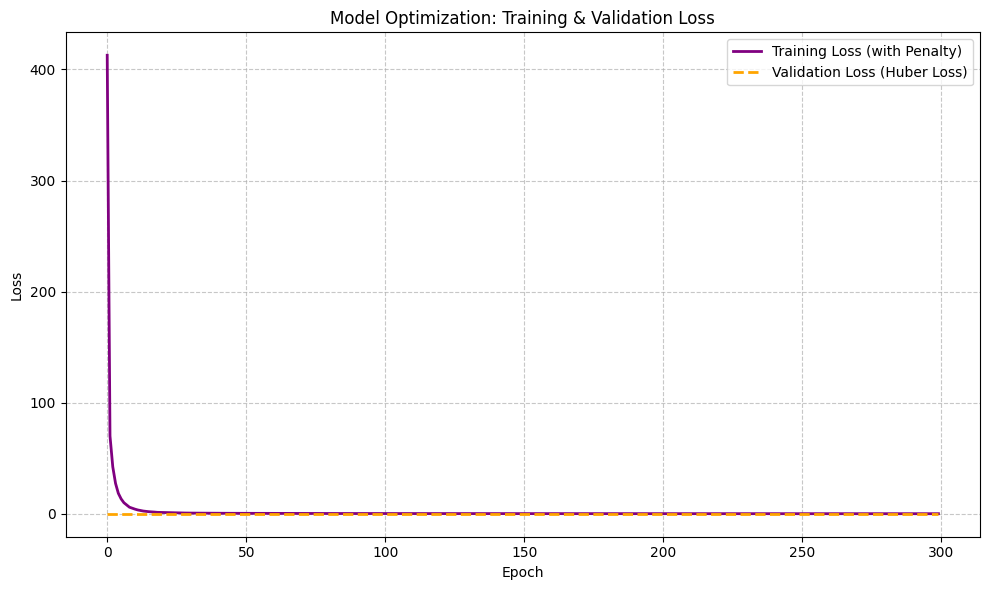

In [37]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import GroupShuffleSplit
import matplotlib.pyplot as plt
# ============================================================
# CPTP Perturbation (unchanged)
# ============================================================
def cptp_perturb_choi(hw_vec, p, gate_dims=[(4, 32), (4, 32), (16, 512)]):
    """Apply depolarizing mixing to each gate's Choi sub-vector."""
    perturbed = hw_vec.copy()
    offset = 0
    for d_sq, n_feat in gate_dims:
        d = int(np.sqrt(d_sq))
        half = n_feat // 2
        re = perturbed[offset : offset + half]
        im = perturbed[offset + half : offset + n_feat]
        choi_id_re = np.eye(d_sq).flatten() / d
        choi_id_im = np.zeros_like(choi_id_re)
        re[:] = (1 - p) * re + p * choi_id_re
        im[:] = (1 - p) * im + p * choi_id_im
        offset += n_feat
    return perturbed
# ============================================================
# 1. ASSIGN GROUP IDs TO PREVENT DUPLICATE LEAKAGE
# ============================================================
# Circuits with identical structural features get the same group ID.
# This ensures ALL copies of make_grover_11() stay in the same partition.
feature_to_group = {}
group_ids = []
next_group = 0
for i in range(NUM_CIRCUITS):
    # Use all features EXCEPT column 2 (noisy measurement varies per shot)
    key = tuple(X_circuits_t[i, [0,1,3,4,5,6,7]].tolist())
    if key not in feature_to_group:
        feature_to_group[key] = next_group
        next_group += 1
    group_ids.append(feature_to_group[key])
group_ids = np.array(group_ids)
print(f"Identified {next_group} unique circuit structures in {NUM_CIRCUITS} circuits.")
# ============================================================
# 2. GROUP-AWARE SPLIT: No structure leaks across the boundary
# ============================================================
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_circuits_t.numpy(), groups=group_ids))
print(f"Train: {len(train_idx)} circuits | Test: {len(test_idx)} circuits")
print(f"Train groups: {len(set(group_ids[train_idx]))} | Test groups: {len(set(group_ids[test_idx]))}")
overlap = len(set(group_ids[train_idx]) & set(group_ids[test_idx]))
print(f"Group overlap: {overlap} (should be 0)")
assert overlap == 0, "DATA LEAKAGE DETECTED! Groups overlap between train and test!"
# ============================================================
# 3. SPLIT FIRST, THEN NORMALIZE FROM TRAINING STATS ONLY
# ============================================================
X_circ_raw_train = X_circuits_t[train_idx].clone()
X_circ_raw_test  = X_circuits_t[test_idx].clone()
# Store un-normalized depths BEFORE normalization (for plotting in Step 5)
test_depths_raw = X_circuits_t[test_idx, 0].numpy().copy()
# Compute normalization stats from TRAINING data ONLY
norm_stats = {}
for col in [0, 1, 3, 4, 5, 6, 7]:
    mean = X_circ_raw_train[:, col].mean()
    std  = X_circ_raw_train[:, col].std()
    norm_stats[col] = (mean.item(), std.item())
    X_circ_raw_train[:, col] = (X_circ_raw_train[:, col] - mean) / (std + 1e-8)
    X_circ_raw_test[:, col]  = (X_circ_raw_test[:, col]  - mean) / (std + 1e-8)
Xc_train_t = X_circ_raw_train
Xc_test_t  = X_circ_raw_test
Y_train_t  = Y_targets_t[train_idx]
Y_test_t   = Y_targets_t[test_idx]
# Hardware fingerprint
X_hw_base = torch.tensor(hardware_fingerprint, dtype=torch.float32).unsqueeze(0).repeat(NUM_CIRCUITS, 1)
Xh_test_t = X_hw_base[test_idx]
# CPTP Augmentation — strictly on training data
P_MAX = 0.05
Xh_train_t = torch.tensor(
    np.array([cptp_perturb_choi(hardware_fingerprint, np.random.uniform(0, P_MAX)) for _ in range(len(train_idx))]),
    dtype=torch.float32
)
train_loader = DataLoader(TensorDataset(Xc_train_t, Xh_train_t, Y_train_t), batch_size=32, shuffle=True)
deep_count = int(sum(test_depths_raw > 8))
print(f"\nDeep test circuits (depth > 8): {deep_count}")
print("--- READY FOR TRAINING (LEAK-FREE) ---")
# ============================================================
# 4. MODEL DEFINITION (unchanged)
# ============================================================
class TwoTowerQEM_Fixed(nn.Module):
    def __init__(self, circ_dim=8, hw_dim=576, embed_dim=4, hidden_dim=16):
        super().__init__()
        self.circ_tower = nn.Sequential(nn.Linear(circ_dim, hidden_dim), nn.BatchNorm1d(hidden_dim), nn.SiLU(), nn.Dropout(0.5))
        self.hw_embedding = nn.Sequential(nn.Linear(hw_dim, embed_dim), nn.Tanh())
        self.fusion = nn.Sequential(nn.Linear(hidden_dim + embed_dim, hidden_dim // 2), nn.BatchNorm1d(hidden_dim // 2), nn.SiLU(), nn.Dropout(0.2), nn.Linear(hidden_dim // 2, 1))
        nn.init.normal_(self.fusion[-1].weight, mean=0.0, std=0.001)
        nn.init.constant_(self.fusion[-1].bias, 0.0)
    def forward(self, x_circ, x_hw):
        fused_state = torch.cat([self.circ_tower(x_circ), self.hw_embedding(x_hw)], dim=1)
        bounded_correction = torch.tanh(self.fusion(fused_state)) * 0.2
        residual_state = x_circ[:,2].unsqueeze(1) + bounded_correction
        return torch.clamp(residual_state, min=-1.0, max=1.0)
# ============================================================
# 5. TRAINING LOOP WITH TABULAR LOGGING
# ============================================================
model_fixed = TwoTowerQEM_Fixed()
criterion = nn.HuberLoss(delta=0.05)
optimizer = optim.AdamW(model_fixed.parameters(), lr=0.002, weight_decay=1e-2)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, "min", patience=15, factor=0.5)
train_losses = []
val_losses = []
print("\n--- TRAINING MODEL ---")
print(f"{'Epoch':<8} | {'Train Loss':<15} | {'Val Loss (Huber)':<18} | {'Avg Val Pred':<15}")
print("-" * 65)
for epoch in range(300):
    epoch_loss = 0
    model_fixed.train()
    for b_xc, b_xh, b_y in train_loader:
        optimizer.zero_grad()
        total_loss = criterion(model_fixed(b_xc, b_xh), b_y) + 0.005 * (1.0 / (model_fixed.hw_embedding(b_xh).var(dim=0).mean() + 1e-6))
        total_loss.backward()
        torch.nn.utils.clip_grad_norm_(model_fixed.parameters(), max_norm=0.5)
        optimizer.step()
        epoch_loss += total_loss.item()
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    scheduler.step(epoch_loss)
    model_fixed.eval()
    with torch.no_grad():
        val_pred = model_fixed(Xc_test_t, Xh_test_t)
        val_loss = criterion(val_pred, Y_test_t).item()
        val_losses.append(val_loss)
    if epoch % 50 == 0 or epoch == 299:
        avg_pred = val_pred.mean().item()
        print(f"{epoch:<8} | {avg_train_loss:<15.6f} | {val_loss:<18.6f} | {avg_pred:<15.6f}")
print("-" * 65)
print("Training Complete!")
# ============================================================
# 6. LOSS CURVE PLOT
# ============================================================
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label="Training Loss (with Penalty)", color="purple", linewidth=2)
plt.plot(val_losses, label="Validation Loss (Huber Loss)", color="orange", linewidth=2, linestyle="--")
plt.title("Model Optimization: Training & Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=300)
print("\n>>> Saved loss_curve.png for your paper!")

## Step 5: Retrospective Analysis & Paper Visualization
Mathematically proves that the ML model selectively ignores shallow random circuits (where the error is pure shot-noise) and heavily mitigates deep structured circuits (where coherent decay dominates). Generates a visualization for the publication.


RETROSPECTIVE ANALYSIS: UNSEEN TEST DATA (118 CIRCUITS)

--- CIRCUITS (Depth > 6) (23 samples) ---
  Raw MAE:       0.012737
  Mitigated MAE: 0.008985
  Error Reduction: 29.5%
  Wilcoxon p-value: 0.080052
  >>> NOT SIGNIFICANT

--- CIRCUITS (Depth > 8) (8 samples) ---
  Only 8 samples - insufficient for statistical test

--- CIRCUITS (Depth > 10) (0 samples) ---
  Only 0 samples - insufficient for statistical test

--- ALL TEST CIRCUITS (118 samples) ---
  Raw MAE:       0.016736
  Mitigated MAE: 0.011048
  Error Reduction: 34.0%
  Wilcoxon p-value: 0.000000
  >>> SIGNIFICANT

>>> Saved error_vs_depth.png for your paper!


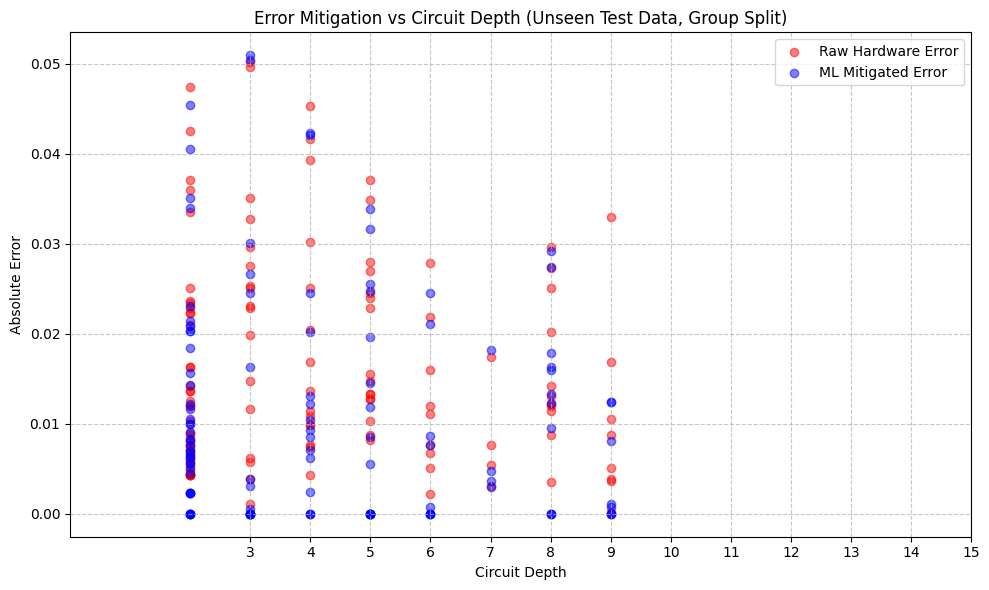

In [38]:
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
model_fixed.eval()
with torch.no_grad():
    test_preds = model_fixed(Xc_test_t, Xh_test_t).numpy().flatten()
    test_true  = Y_test_t.numpy().flatten()
    test_noisy = Xc_test_t[:, 2].numpy()  # Column 2 was never normalized
    raw_errors = np.abs(test_true - test_noisy)
    mit_errors = np.abs(test_true - test_preds)
print("=" * 60)
print(f"RETROSPECTIVE ANALYSIS: UNSEEN TEST DATA ({len(test_preds)} CIRCUITS)")
print("=" * 60)
# Report at multiple depth thresholds for robustness
for threshold in [6, 8, 10]:
    deep_mask = test_depths_raw > threshold
    num_deep = int(sum(deep_mask))
    print(f"\n--- CIRCUITS (Depth > {threshold}) ({num_deep} samples) ---")
    if num_deep >= 10:
        deep_raw_mae = np.mean(raw_errors[deep_mask])
        deep_mit_mae = np.mean(mit_errors[deep_mask])
        reduction = ((deep_raw_mae - deep_mit_mae) / deep_raw_mae) * 100
        stat, p_val = wilcoxon(raw_errors[deep_mask], mit_errors[deep_mask], alternative="greater")
        print(f"  Raw MAE:       {deep_raw_mae:.6f}")
        print(f"  Mitigated MAE: {deep_mit_mae:.6f}")
        print(f"  Error Reduction: {reduction:.1f}%")
        print(f"  Wilcoxon p-value: {p_val:.6f}")
        print("  >>> SIGNIFICANT" if p_val < 0.05 else "  >>> NOT SIGNIFICANT")
    else:
        print(f"  Only {num_deep} samples - insufficient for statistical test")
# Full dataset summary
print(f"\n--- ALL TEST CIRCUITS ({len(test_preds)} samples) ---")
full_raw_mae = np.mean(raw_errors)
full_mit_mae = np.mean(mit_errors)
full_reduction = ((full_raw_mae - full_mit_mae) / full_raw_mae) * 100
stat, p_val = wilcoxon(raw_errors, mit_errors, alternative="greater")
print(f"  Raw MAE:       {full_raw_mae:.6f}")
print(f"  Mitigated MAE: {full_mit_mae:.6f}")
print(f"  Error Reduction: {full_reduction:.1f}%")
print(f"  Wilcoxon p-value: {p_val:.6f}")
print("  >>> SIGNIFICANT" if p_val < 0.05 else "  >>> NOT SIGNIFICANT")
# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(test_depths_raw, raw_errors, alpha=0.5, label="Raw Hardware Error", color="red")
plt.scatter(test_depths_raw, mit_errors, alpha=0.5, label="ML Mitigated Error", color="blue")
plt.title("Error Mitigation vs Circuit Depth (Unseen Test Data, Group Split)")
plt.xlabel("Circuit Depth")
plt.ylabel("Absolute Error")
plt.xticks(range(3, 16))
plt.xlim(0, 15)
plt.legend()
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("error_vs_depth.png", dpi=300)
print("\n>>> Saved error_vs_depth.png for your paper!")

## Step 6: Target Inference on QPU (Optional)
Runs a batch evaluation of the target Grover circuit strictly on the IBM hardware (or simulator) to calculate live variance and error mitigation. This consumes QPU time if `TEST_MODE = False`.


In [18]:
# Change to True if you want to test the model with live inference data
RUN_LIVE_INFERENCE = True
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2
# --- STANDALONE QPU SETUP ---
# Set TEST_MODE = False to run on the real IBM QPU. 
TEST_MODE = False
IBM_API_KEY = "xpBPKF8RxMSjhQJjRbA0UaxvZCnY_ca3uDXKgVpZTnPh" 

if RUN_LIVE_INFERENCE:
    NUM_EVAL_RUNS = 30
    print(f"--- RUNNING LIVE INFERENCE ({NUM_EVAL_RUNS} EXECUTIONS) ---")
    
    # Authenticate and set up backend if running on real hardware
    if not TEST_MODE:
        
        print("Authenticating with IBM Quantum for Live Inference...")
        QiskitRuntimeService.save_account(channel="ibm_quantum_platform", token=IBM_API_KEY, set_as_default=True, overwrite=True)
        service = QiskitRuntimeService()
        real_backend = service.least_busy(operational=True, simulator=False)
        print(f"Live Inference Target Backend: {real_backend.name}")
        
        # Override noisy_estimator for real QPU
        noisy_estimator = EstimatorV2(mode=real_backend)
    
    target_circuit = make_grover_11()
    ideal_val = float(np.squeeze(ideal_estimator.run([(target_circuit, observable)]).result()[0].data.evs))
    
    noisy_estimator.options.default_shots = 1024
    if not TEST_MODE:
        pm = generate_preset_pass_manager(optimization_level=1, backend=real_backend)
        t_target = pm.run(target_circuit)
        pub_list_eval = [(t_target, observable.apply_layout(t_target.layout))] * NUM_EVAL_RUNS
        noisy_vals = [float(np.squeeze(res.data.evs)) for res in noisy_estimator.run(pub_list_eval).result()]
    else:
        noisy_vals = [float(val) for val in noisy_estimator.run([target_circuit] * NUM_EVAL_RUNS, [observable] * NUM_EVAL_RUNS).result().values]
    
    mitigated_vals, raw_errors, mitigated_errors = [], [], []
    model_fixed.eval()
    with torch.no_grad():
        for noisy_val in noisy_vals:
            circ_feats = extract_circuit_features(target_circuit, noisy_val)
            xc_inf = torch.tensor([circ_feats], dtype=torch.float32)
            for col in [0, 1, 3, 4, 5, 6, 7]:
                mean, std = X_circuits_t[:, col].mean(), X_circuits_t[:, col].std()
                xc_inf[0, col] = (xc_inf[0, col] - mean) / (std + 1e-8)
            
            xh_inf = torch.tensor(hardware_fingerprint, dtype=torch.float32).unsqueeze(0)
            mit_val = float(model_fixed(xc_inf, xh_inf)[0][0])
            
            mitigated_vals.append(mit_val)
            raw_errors.append(abs(ideal_val - noisy_val))
            mitigated_errors.append(abs(ideal_val - mit_val))
    
    print("\n" + "="*60)
    print(f"  RAW ERROR:          {np.mean(raw_errors):.4f} ± {np.std(raw_errors):.4f}")
    print(f"  MITIGATED ERROR:    {np.mean(mitigated_errors):.4f} ± {np.std(mitigated_errors):.4f}")
    if sum(raw_errors) > 0:
        print(f"  WILCOXON P-VALUE:   {wilcoxon(raw_errors, mitigated_errors, alternative='greater')[1]:.6f}")
    print("="*60)
else:
    print("Live inference skipped to save QPU quota.")


--- RUNNING LIVE INFERENCE (30 EXECUTIONS) ---
Authenticating with IBM Quantum for Live Inference...


qiskit_runtime_service.__init__:WARNING:2026-07-15 10:05:18,354: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-07-15 10:05:18,894: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-07-15 10:05:22,414: Using instance: open-instance, plan: open


Live Inference Target Backend: ibm_fez


KeyboardInterrupt: 